In [5]:
import pandas as pd

data = pd.read_csv("spam.csv", encoding='latin-1')
data = data[['v1','v2']]
data.columns = ['label','message']

print(data.head())
print(data.info())
print(data.describe())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB
None
       label                 message
count   5572                    5572
unique     2                    5169
top      ham  Sorry, I'll call later
freq    4825                      30


In [6]:
import pandas as pd

data = pd.read_csv("spam.csv", encoding='latin-1')
data = data[['v1','v2']]
data.columns = ['label','message']

print(data['label'].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


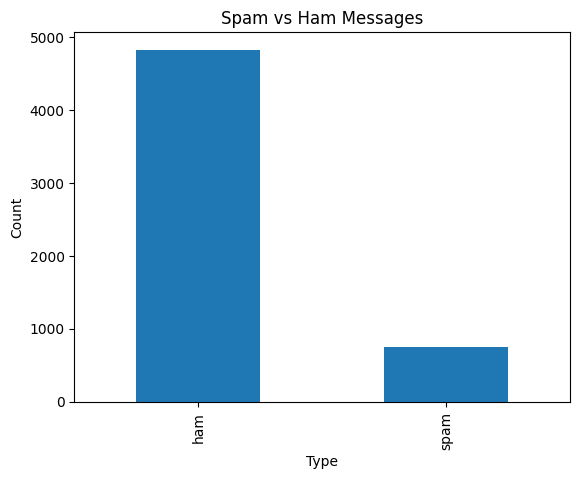

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("spam.csv", encoding='latin-1')
data = data[['v1','v2']]
data.columns = ['label','message']

data['label'].value_counts().plot(kind='bar')

plt.title("Spam vs Ham Messages")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

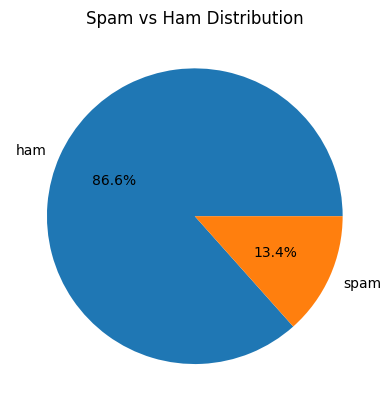

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("spam.csv", encoding='latin-1')
data = data[['v1','v2']]
data.columns = ['label','message']

data['label'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Spam vs Ham Distribution")
plt.ylabel("")
plt.show()

In [9]:
import pandas as pd

data = pd.read_csv("spam.csv", encoding='latin-1')
data = data[['v1','v2']]
data.columns = ['label','message']

data['length'] = data['message'].apply(len)

print(data.head())

  label                                            message  length
0   ham  Go until jurong point, crazy.. Available only ...     111
1   ham                      Ok lar... Joking wif u oni...      29
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...     155
3   ham  U dun say so early hor... U c already then say...      49
4   ham  Nah I don't think he goes to usf, he lives aro...      61


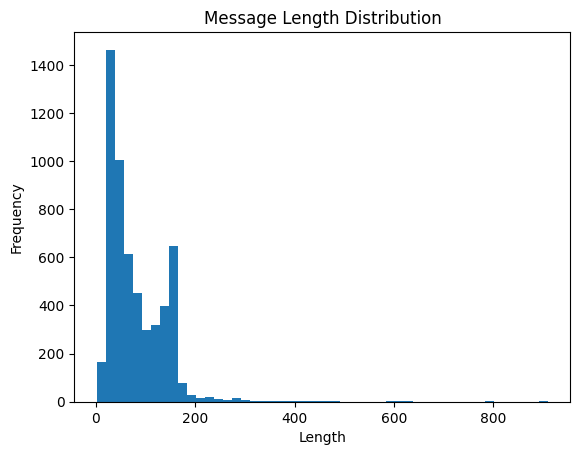

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("spam.csv", encoding='latin-1')
data = data[['v1','v2']]
data.columns = ['label','message']

data['length'] = data['message'].apply(len)

plt.hist(data['length'], bins=50)

plt.title("Message Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

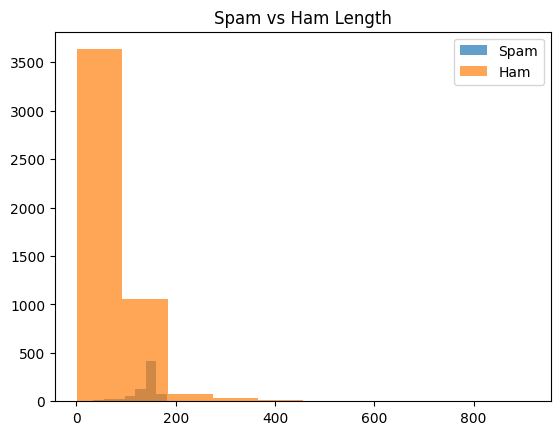

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("spam.csv", encoding='latin-1')
data = data[['v1','v2']]
data.columns = ['label','message']

data['length'] = data['message'].apply(len)

spam = data[data['label']=="spam"]
ham = data[data['label']=="ham"]

plt.hist(spam['length'], alpha=0.7, label="Spam")
plt.hist(ham['length'], alpha=0.7, label="Ham")

plt.legend()
plt.title("Spam vs Ham Length")
plt.show()

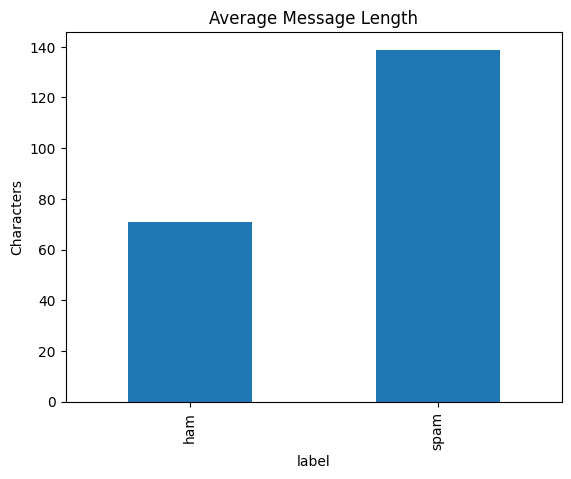

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("spam.csv", encoding='latin-1')
data = data[['v1','v2']]
data.columns = ['label','message']

data['length'] = data['message'].apply(len)

avg = data.groupby('label')['length'].mean()

avg.plot(kind='bar')

plt.title("Average Message Length")
plt.ylabel("Characters")
plt.show()

In [13]:
import pandas as pd

data = pd.read_csv("spam.csv", encoding='latin-1')
data = data[['v1','v2']]
data.columns = ['label','message']

data['word_count'] = data['message'].apply(lambda x: len(x.split()))

print(data.head())

  label                                            message  word_count
0   ham  Go until jurong point, crazy.. Available only ...          20
1   ham                      Ok lar... Joking wif u oni...           6
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...          28
3   ham  U dun say so early hor... U c already then say...          11
4   ham  Nah I don't think he goes to usf, he lives aro...          13


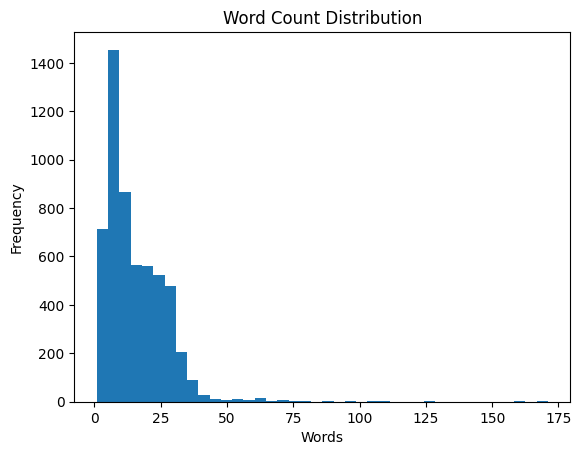

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("spam.csv", encoding='latin-1')
data = data[['v1','v2']]
data.columns = ['label','message']

data['word_count'] = data['message'].apply(lambda x: len(x.split()))

plt.hist(data['word_count'], bins=40)

plt.title("Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [15]:
import pandas as pd
from collections import Counter

data = pd.read_csv("spam.csv", encoding='latin-1')
data = data[['v1','v2']]
data.columns = ['label','message']

all_words = " ".join(data['message']).split()

common = Counter(all_words).most_common(10)

print(common)

[('to', 2134), ('you', 1622), ('I', 1466), ('a', 1327), ('the', 1197), ('and', 857), ('in', 798), ('is', 781), ('i', 742), ('u', 692)]


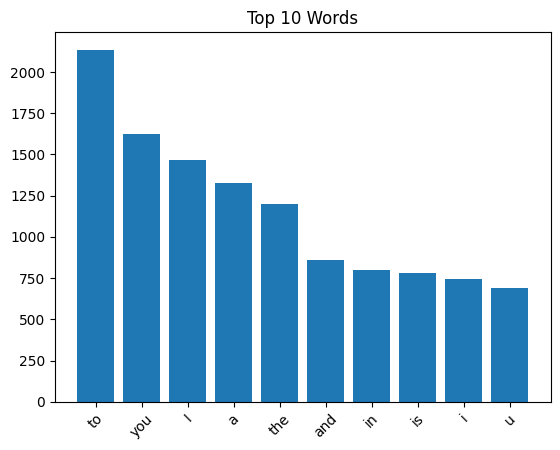

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

data = pd.read_csv("spam.csv", encoding='latin-1')
data = data[['v1','v2']]
data.columns = ['label','message']

words = " ".join(data['message']).split()
common = Counter(words).most_common(10)

word = [i[0] for i in common]
count = [i[1] for i in common]

plt.bar(word, count)

plt.title("Top 10 Words")
plt.xticks(rotation=45)
plt.show()

In [17]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

data = pd.read_csv("spam.csv", encoding='latin-1')
data = data[['v1','v2']]
data.columns = ['label','message']

x = data['message']
y = data['label']

cv = CountVectorizer()
x = cv.fit_transform(x)

xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size=0.2)

model = MultinomialNB()
model.fit(xtrain,ytrain)

print("Accuracy:", model.score(xtest,ytest))

Accuracy: 0.9829596412556054


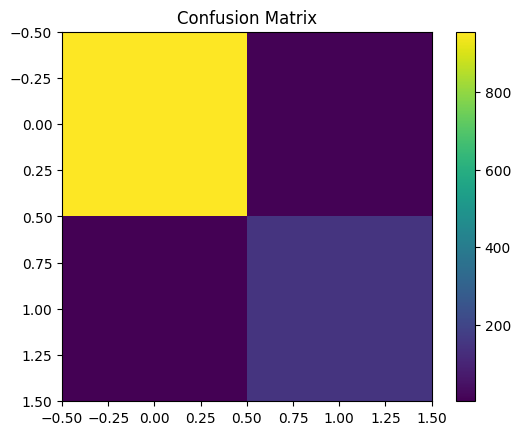

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

data = pd.read_csv("spam.csv", encoding='latin-1')
data = data[['v1','v2']]
data.columns = ['label','message']

x = data['message']
y = data['label']

cv = CountVectorizer()
x = cv.fit_transform(x)

xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size=0.2)

model = MultinomialNB()
model.fit(xtrain,ytrain)

pred = model.predict(xtest)

cm = confusion_matrix(ytest,pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

In [19]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

data = pd.read_csv("spam.csv", encoding='latin-1')
data = data[['v1','v2']]
data.columns = ['label','message']

cv = CountVectorizer()
x = cv.fit_transform(data['message'])

model = MultinomialNB()
model.fit(x,data['label'])

msg = ["Congratulations! You won a free prize"]

msg_vec = cv.transform(msg)

print(model.predict(msg_vec))

['spam']


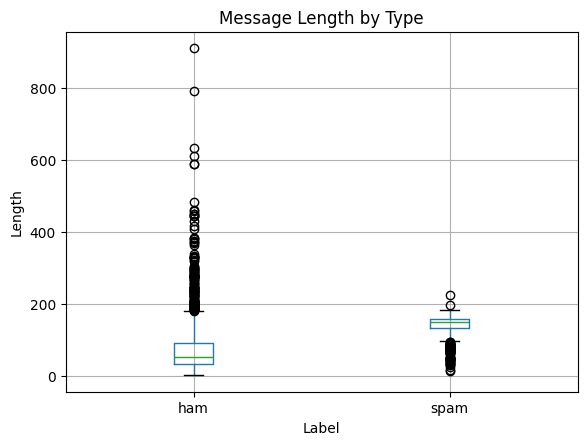

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("spam.csv", encoding="latin-1")
data = data[['v1','v2']]
data.columns = ['label','message']

data['length'] = data['message'].apply(len)

data.boxplot(column='length', by='label')

plt.title("Message Length by Type")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("Length")
plt.show()

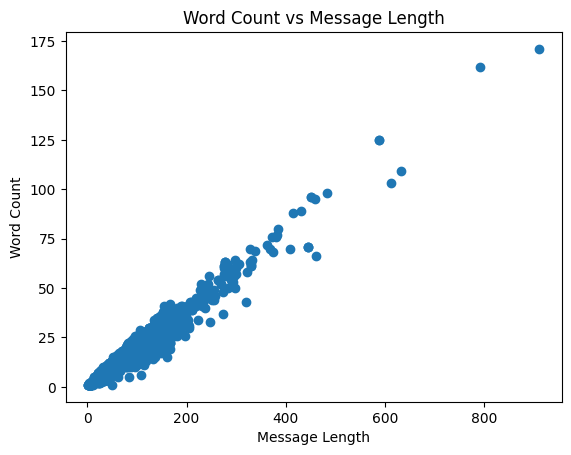

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("spam.csv", encoding="latin-1")
data = data[['v1','v2']]
data.columns = ['label','message']

data['length'] = data['message'].apply(len)
data['word_count'] = data['message'].apply(lambda x: len(x.split()))

plt.scatter(data['length'], data['word_count'])

plt.title("Word Count vs Message Length")
plt.xlabel("Message Length")
plt.ylabel("Word Count")
plt.show()

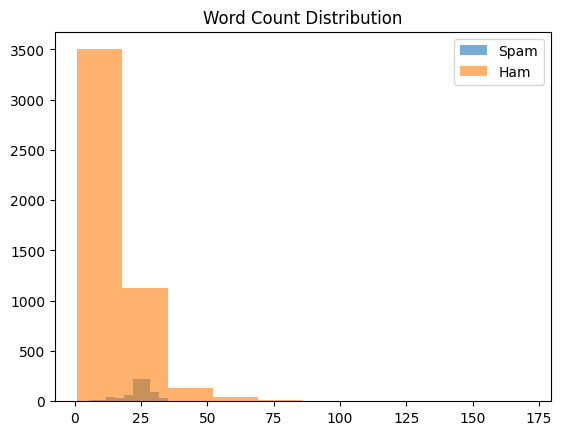

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("spam.csv", encoding="latin-1")
data = data[['v1','v2']]
data.columns = ['label','message']

data['word_count'] = data['message'].apply(lambda x: len(x.split()))

spam = data[data['label']=="spam"]
ham = data[data['label']=="ham"]

plt.hist(spam['word_count'], alpha=0.6, label="Spam")
plt.hist(ham['word_count'], alpha=0.6, label="Ham")

plt.legend()
plt.title("Word Count Distribution")
plt.show()

In [23]:
import pandas as pd
from collections import Counter

data = pd.read_csv("spam.csv", encoding="latin-1")
data = data[['v1','v2']]
data.columns = ['label','message']

spam = data[data['label']=="spam"]

words = " ".join(spam['message']).split()

top = Counter(words).most_common(15)

print(top)

[('to', 604), ('a', 358), ('your', 187), ('call', 185), ('or', 185), ('the', 178), ('2', 169), ('for', 169), ('you', 164), ('is', 143), ('Call', 136), ('on', 135), ('have', 128), ('and', 119), ('from', 116)]


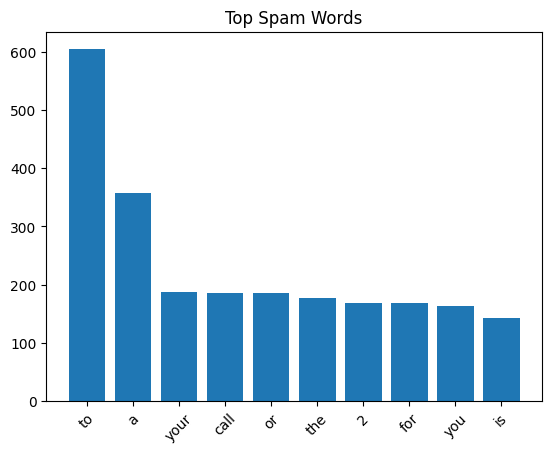

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

data = pd.read_csv("spam.csv", encoding="latin-1")
data = data[['v1','v2']]
data.columns = ['label','message']

spam = data[data['label']=="spam"]

words = " ".join(spam['message']).split()

top = Counter(words).most_common(10)

w = [i[0] for i in top]
c = [i[1] for i in top]

plt.bar(w,c)

plt.title("Top Spam Words")
plt.xticks(rotation=45)
plt.show()